In [23]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("../data/owid-co2-data.csv")
important_cols = [
    "country",
    "year",
    "co2",
    "co2_per_capita",
    "population",
    "gdp",
    "coal_co2",
    "oil_co2",
    "gas_co2",
    "iso_code",
    "methane",
    "total_ghg",
    "primary_energy_consumption",
    "temperature_change_from_co2"
] 

df_clean = df[important_cols]

df_world= df_clean[df_clean['country'] == 'World']

# Plot
plt.figure(figsize=(12,6))
plt.plot(world["year"], world["co2"])

plt.title("Global CO₂ Emissions Over Time")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions")
plt.grid(True)

plt.show()

NameError: name 'world' is not defined

<Figure size 1200x600 with 0 Axes>

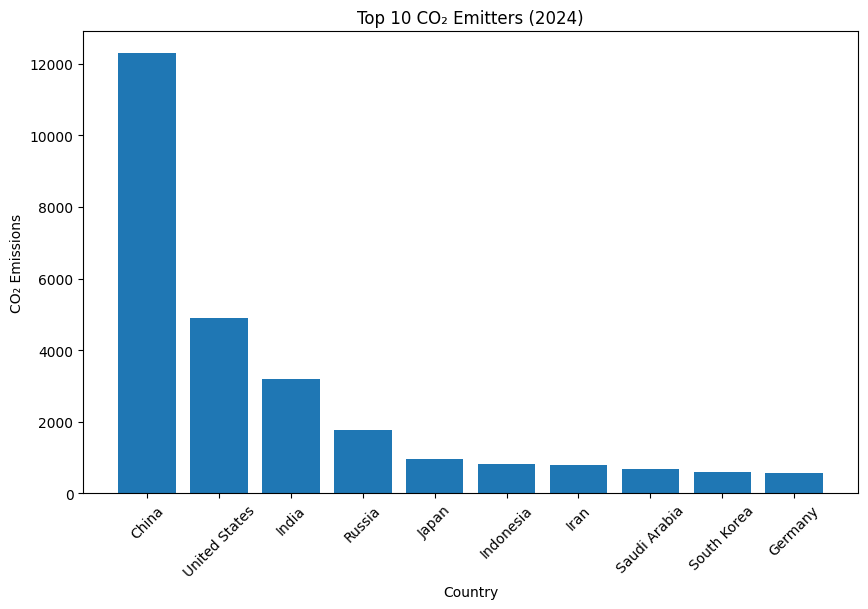

In [ ]:
df_country = df_clean[
    (df_clean["iso_code"].notna()) &
    (df_clean["iso_code"].str.len() == 3)
]
latest_year = df_country["year"].max()

top_emitters = (
    df_country[df_country["year"] == latest_year]
    .sort_values("co2", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
plt.bar(top_emitters["country"], top_emitters["co2"])

plt.title(f"Top 10 CO₂ Emitters ({latest_year})")
plt.xlabel("Country")
plt.ylabel("CO₂ Emissions")
plt.xticks(rotation=45)

plt.show()


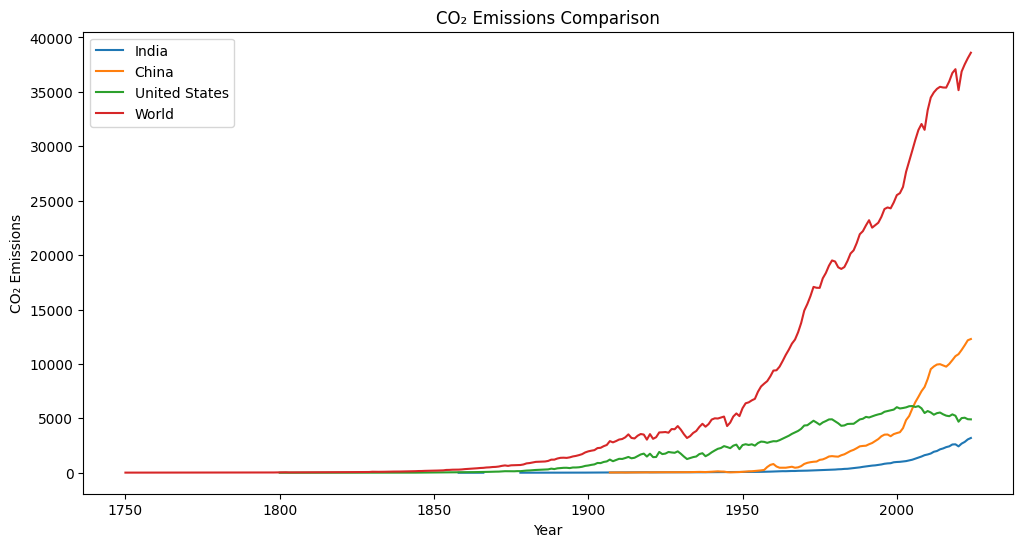

2024


In [ ]:
countries = ["India", "China", "United States", "World"]

df_compare = df_clean[
    df_clean["country"].isin(countries)
]

plt.figure(figsize=(12,6))

for country in countries:
    temp = df_compare[df_compare["country"] == country]
    plt.plot(temp["year"], temp["co2"], label=country)

plt.legend()
plt.title("CO₂ Emissions Comparison")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions")

plt.show()
print(df_compare["year"].max()) 

Latest GDP Year: 2022
(164, 3)


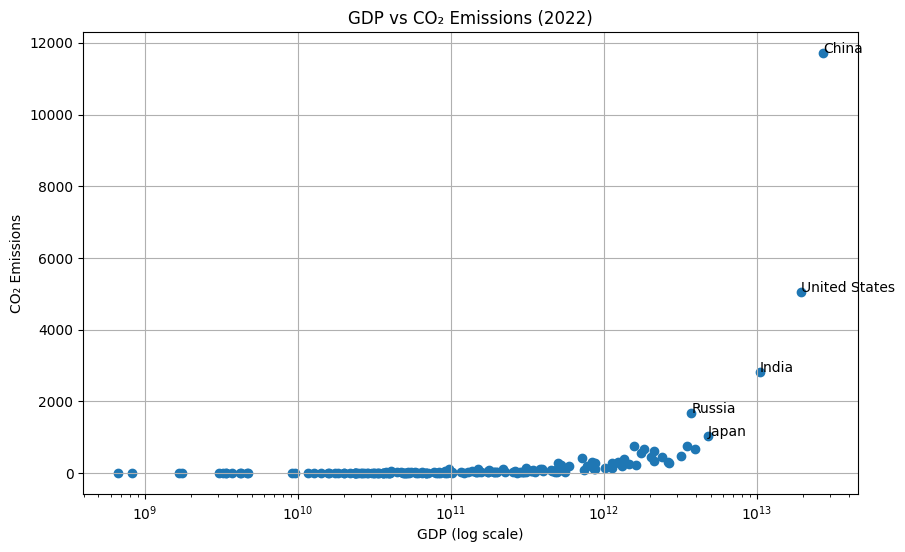

In [ ]:
gdp_data = df_country[df_country["gdp"].notna()]

latest_gdp_year = gdp_data["year"].max()

print("Latest GDP Year:", latest_gdp_year)
scatter_data = gdp_data[
    gdp_data["year"] == latest_gdp_year
][["country","gdp","co2"]].dropna()

print(scatter_data.shape)
plt.figure(figsize=(10,6))

plt.scatter(
    scatter_data["gdp"],
    scatter_data["co2"]
)

plt.xscale("log")

plt.title(f"GDP vs CO₂ Emissions ({latest_gdp_year})")
plt.xlabel("GDP (log scale)")
plt.ylabel("CO₂ Emissions")
plt.grid(True)
for _, row in scatter_data.nlargest(5, "co2").iterrows():
    plt.annotate(
        row["country"],
        (row["gdp"], row["co2"])
    )

plt.show()


 Insight

Positive relationship exists
Countries with higher GDP generally emit more CO₂.
Economic growth is associated with increased energy use and industrial activity.
Not perfectly linear
Countries with similar GDP can have very different emissions.
This suggests differences in energy efficiency, renewable energy adoption, and industrial structure.
A few countries dominate
The points in the top-right corner represent large economies with very high emissions (likely China, USA, India).
Most countries cluster at lower GDP levels
Many nations have relatively low GDP and low emissions

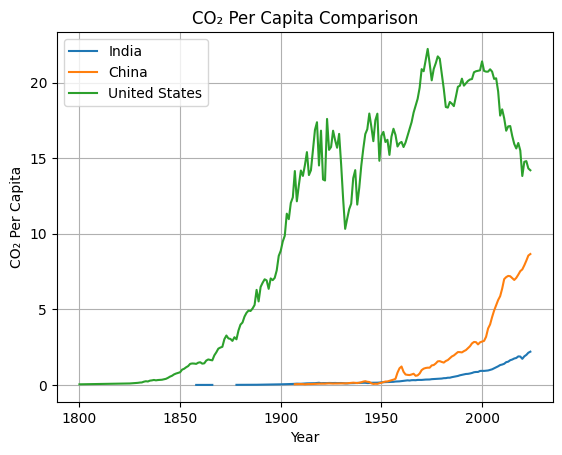

In [ ]:
countries = ["India", "China", "United States"]

for country in countries:
    data = df_country[df_country["country"] == country]
    plt.plot(
        data["year"],
        data["co2_per_capita"],
        label=country
    )

plt.legend()
plt.title("CO₂ Per Capita Comparison")
plt.xlabel("Year")
plt.ylabel("CO₂ Per Capita")
plt.grid(True)
plt.show()

In [ ]:
latest_data = energy_data[
    energy_data["year"] == latest_year
]

plt.figure(figsize=(12,6))

plt.scatter(
    latest_data["primary_energy_consumption"],
    latest_data["co2"]
)

# Label top 10 emitters only
top10 = latest_data.nlargest(10, "co2")

for _, row in top10.iterrows():
    plt.annotate(
        row["country"],
        (row["primary_energy_consumption"], row["co2"]),
        fontsize=9
    )

plt.title(f"Energy Consumption vs CO₂ Emissions ({latest_year})")
plt.xlabel("Primary Energy Consumption")
plt.ylabel("CO₂ Emissions")
plt.grid(True)

plt.show()

NameError: name 'energy_data' is not defined

Insight

-A strong positive relationship exists between energy consumption and CO₂ emissions.
-Countries with higher energy usage tend to generate significantly larger carbon emissions.
-A small number of countries account for a disproportionate share of global energy consumption and emissions.

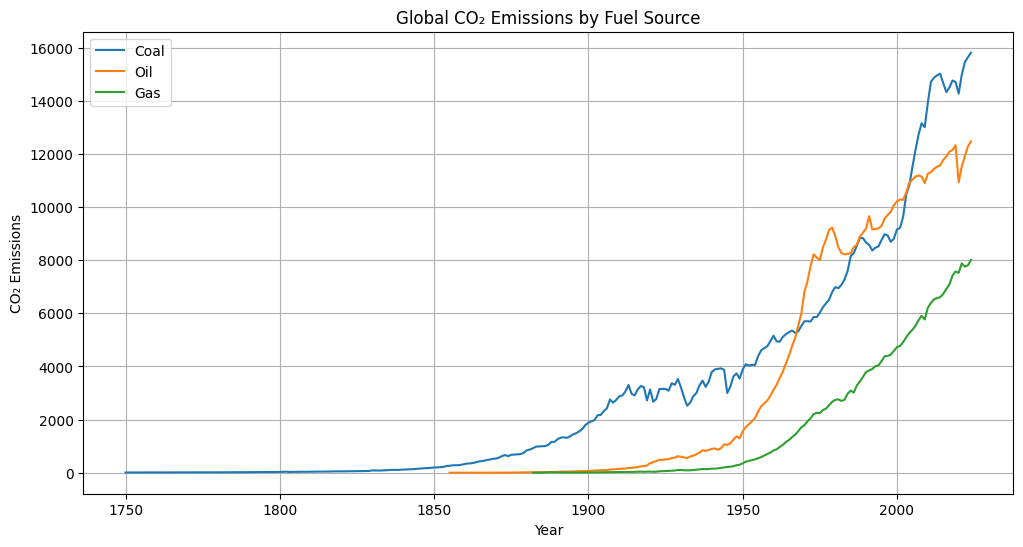

In [ ]:
world = df_clean[df_clean["country"] == "World"]

plt.figure(figsize=(12,6))

plt.plot(world["year"], world["coal_co2"], label="Coal")
plt.plot(world["year"], world["oil_co2"], label="Oil")
plt.plot(world["year"], world["gas_co2"], label="Gas")

plt.title("Global CO₂ Emissions by Fuel Source")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions")
plt.legend()
plt.grid(True)

plt.show()

Insight
Coal remains the largest contributor to CO₂ emissions.
Oil emissions increased with industrialization and transportation.
Gas emissions have grown rapidly in recent decades.


1. Global Emissions Trend
Global CO₂ emissions have risen dramatically since the Industrial Revolution.
Growth accelerated after 1950.
2. Top Emitters
China is currently the largest emitter.
The United States remains one of the highest contributors.
India is growing rapidly but still trails China and the US in total emissions.
3. GDP vs CO₂
Economic growth and emissions are positively correlated.
Larger economies generally produce more emissions.
4. Per Capita Emissions
The US has much higher emissions per person than India.
India's total emissions are high largely because of its large population.
5. Energy vs Emissions
Countries consuming more energy tend to emit more CO₂.
A few countries dominate both energy use and emissions.
6. Fuel Sources
Coal is the largest contributor to global CO₂ emissions.
Oil and gas have become increasingly important over time.

In [24]:
df_clean.to_csv("../data/carbon_clean.csv", index=False)